In [70]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
import os
import json
import math
import numpy as np
import pandas as pd

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.colors import to_rgb
import matplotlib

## PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

from modele import BasicUNet
from data import load_data, DEFAULT_MEAN, DEFAULT_STD
from helpers import set_seed, denormalize, save_samples, corrupt
from train import train_diffusion, sample_diffusion

In [72]:
device = torch.device("cuda:2") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cpu


In [ ]:
set_seed(42)

dataset, train_dataset, test_dataset, train_loader, test_loader = load_data(
    root="trafic_32",
    batch_size=64,
    split=0.8,
    mean=DEFAULT_MEAN,
    std=DEFAULT_STD,
    seed=42,
 )

In [74]:
for images, labels in train_loader:
    print(images.shape)  # [batch_size, 3, 32, 32]
    print(labels.shape)  # [batch_size]
    break

torch.Size([8, 3, 32, 32])
torch.Size([8])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


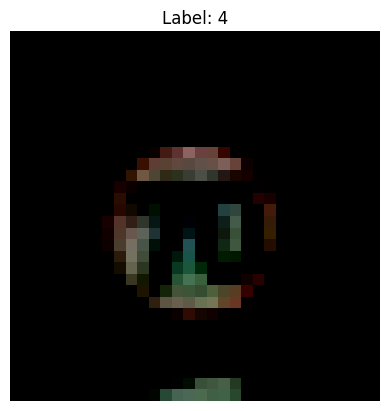

In [75]:
image, label = train_dataset[100]

# PyTorch tensor → HWC for plotting
img = image.permute(1, 2, 0)

plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [76]:
# all_samples = torch.stack([sample[0] for sample in train_dataset])
# print(f"Data norm: mean={all_samples.mean():.4f} | std={all_samples.std():.4f}")
# print(f"Data norm per channel: mean={all_samples.mean(axis=(0,2,3))} | std={all_samples.std(axis=(0,2,3))}")

# Data norm: mean=0.3041 | std=0.2704
# Data norm per channel: mean=tensor([0.3184, 0.2927, 0.3013]) | std=tensor([0.2763, 0.2655, 0.2686])

In [77]:
# corrupt is imported from helpers.py

Input shape: torch.Size([8, 3, 32, 32])


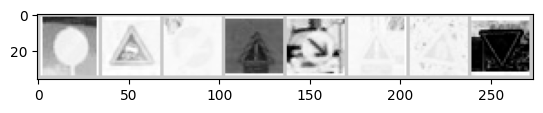

In [78]:
x, y = next(iter(train_loader))
x = x[:8]
print('Input shape:', x.shape)
plt.imshow(torchvision.utils.make_grid(x)[0], cmap='Greys');

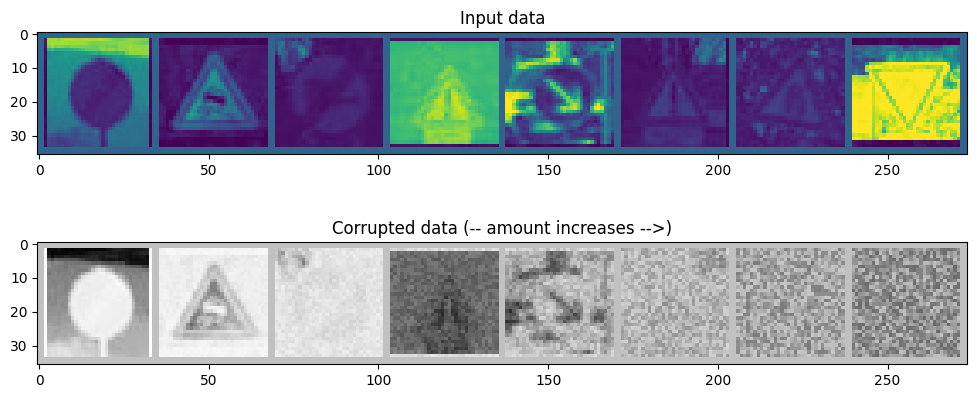

In [79]:
# Plotting the input data
fig, axs = plt.subplots(2, 1, figsize=(12, 5))
axs[0].set_title('Input data')
axs[0].imshow(torchvision.utils.make_grid(x)[0])

# Adding noise
amount = torch.linspace(0, 1, x.shape[0]) # Left to right -> more corruption
noised_x = corrupt(x, amount)

# Plotting the noised version
axs[1].set_title('Corrupted data (-- amount increases -->)')
axs[1].imshow(torchvision.utils.make_grid(noised_x)[0], cmap='Greys');

In [80]:
net = BasicUNet().to(device)
net

BasicUNet(
  (down_layers): ModuleList(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (2): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  )
  (up_layers): ModuleList(
    (0): Conv2d(65, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (2): Conv2d(32, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  )
  (act): SiLU()
  (downscale): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (upscale): Upsample(scale_factor=2.0, mode='nearest')
)

Finished epoch 0. Average loss for this epoch: 0.280773
Finished epoch 1. Average loss for this epoch: 0.249083
Finished epoch 2. Average loss for this epoch: 0.240252
Finished epoch 3. Average loss for this epoch: 0.246110
Finished epoch 4. Average loss for this epoch: 0.409983


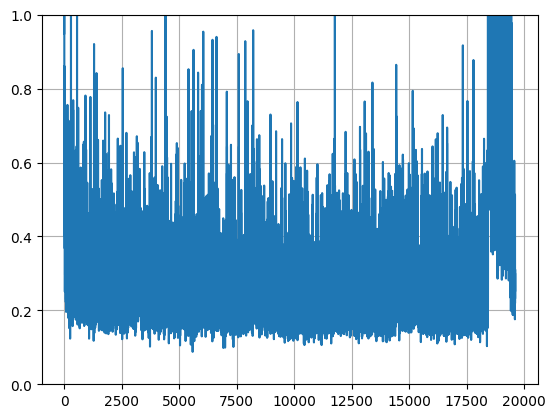

In [81]:
n_epochs = 5

net = BasicUNet(in_channels=3).to(device)

losses = train_diffusion(
    net,
    train_loader,
    device,
    epochs=n_epochs,
    lr=1e-3,
 )

plt.plot(losses)
plt.ylim(0, 1.0)
plt.grid(True)
plt.show()

(-0.5, 273.5, 273.5, -0.5)

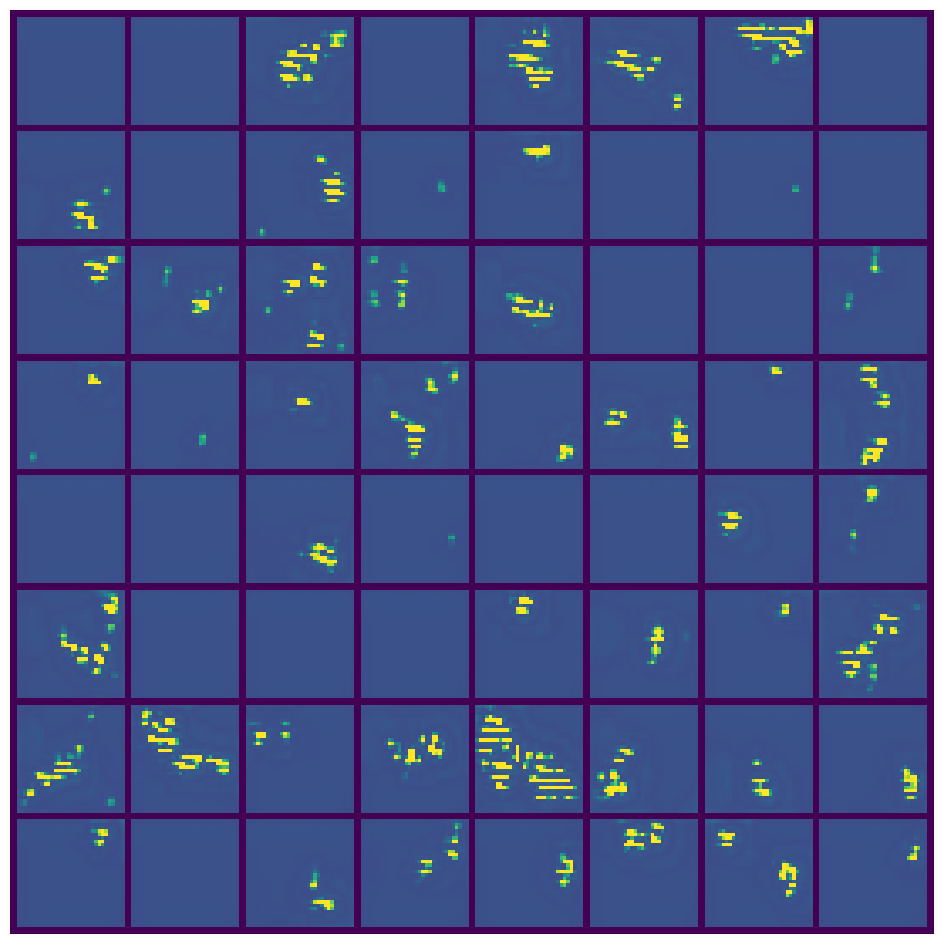

In [82]:
samples = sample_diffusion(
    net,
    device,
    num_samples=64,
    steps=40,
    img_shape=(3, 32, 32),
 )

samples_vis = denormalize(samples, DEFAULT_MEAN, DEFAULT_STD)

fig, ax = plt.subplots(1, 1, figsize=(12, 12))
ax.imshow(torchvision.utils.make_grid(samples_vis.detach().cpu(), nrow=8)[0].clip(0, 1))
ax.axis('off')

In [83]:
generated = sample_diffusion(
    net,
    device,
    num_samples=1000,
    steps=40,
    img_shape=(3, 32, 32),
 )

generated = denormalize(generated, DEFAULT_MEAN, DEFAULT_STD)

save_samples(generated, "generated_diffusion.pt")
generated.shape

torch.Size([1000, 3, 32, 32])